In [55]:
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# loading the Superstore dataset
# windows-1252 encoding was required — default utf-8 raised a read error
df = pd.read_csv('/content/drive/MyDrive/Planilhas - Dados/Projeto 03 - Superstore/Sample - Superstore.csv', encoding='windows-1252')

# converting date columns from string to datetime
# so we can extract year and month later
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [63]:
# overall sales and profit totals to get a general sense of scale
print(df['Sales'].sum())
print(df['Profit'].sum())

# Order ID repeats because a single order can contain multiple products
print(f'Unique orders (Order ID): {df["Order ID"].nunique()}')

2297200.8603000003
286397.0217
Unique orders (Order ID): 5009


In [64]:
# breaking down sales, profit and average discount by category
# to identify where revenue and margin are coming from
print(df.groupby('Category')['Sales'].sum())
print('\n')
print(df.groupby('Category')['Profit'].sum())
print('\n')
print(df.groupby('Category')['Discount'].mean())

# Technology leads in sales, but Furniture stands out for its low profit
# will investigate Furniture further

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64


In [65]:
# filtering Furniture only to understand what is dragging its result down
furniture_df = df[df['Category'] == 'Furniture']

# drilling down to sub-category level
print(furniture_df.groupby('Sub-Category')['Sales'].sum())
print('\n')
print(furniture_df.groupby('Sub-Category')['Profit'].sum())
print('\n')
print(furniture_df.groupby('Sub-Category')['Discount'].mean())

# Tables and Bookcases show negative profit — worth a closer look

Sub-Category
Bookcases      114879.9963
Chairs         328449.1030
Furnishings     91705.1640
Tables         206965.5320
Name: Sales, dtype: float64


Sub-Category
Bookcases      -3472.5560
Chairs         26590.1663
Furnishings    13059.1436
Tables        -17725.4811
Name: Profit, dtype: float64


Sub-Category
Bookcases      0.211140
Chairs         0.170178
Furnishings    0.138349
Tables         0.261285
Name: Discount, dtype: float64


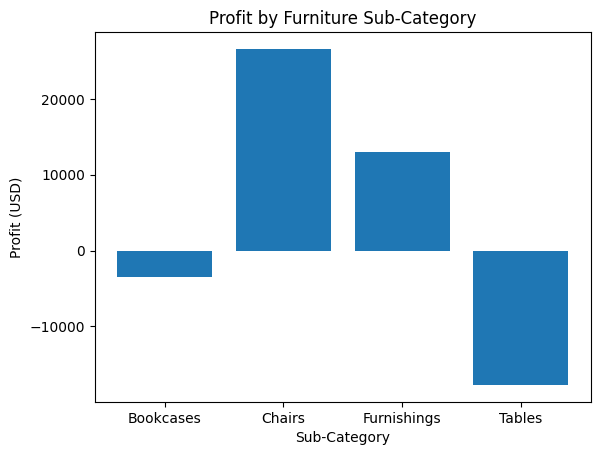

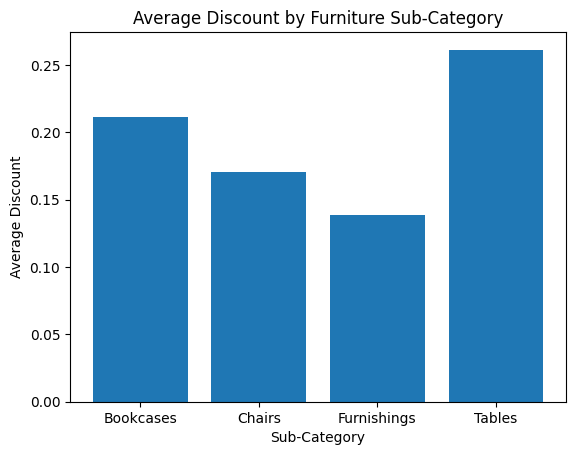

In [66]:
# profit by Furniture sub-category — visualizing where the losses are
sub_categoria = furniture_df.groupby('Sub-Category')['Profit'].sum()

plt.bar(
    sub_categoria.index,
    sub_categoria.values
)
plt.xlabel('Sub-Category')
plt.ylabel('Profit (USD)')
plt.title('Profit by Furniture Sub-Category')
plt.show()

# average discount by sub-category — checking if discounts explain the losses
sub_categoria_discount = furniture_df.groupby('Sub-Category')['Discount'].mean()

plt.bar(
    sub_categoria_discount.index,
    sub_categoria_discount.values
)
plt.xlabel('Sub-Category')
plt.ylabel('Average Discount')
plt.title('Average Discount by Furniture Sub-Category')
plt.show()

# discounts are higher in the problematic sub-categories, but don't fully explain the negative margins

/tmp/ipykernel_2799/1972279119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furniture_df['Profit Margin'] = furniture_df['Profit'] / furniture_df['Sales']


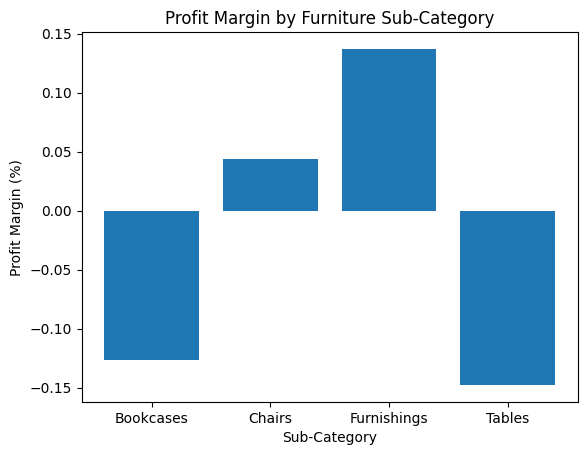

In [67]:
# calculating profit margin by sub-category (Profit / Sales)
# margin allows efficiency comparison, not just absolute profit values
furniture_df['Profit Margin'] = furniture_df['Profit'] / furniture_df['Sales']

ml_df = furniture_df.groupby('Sub-Category')['Profit Margin'].mean()

plt.bar(ml_df.index, ml_df.values)
plt.xlabel('Sub-Category')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin by Furniture Sub-Category')
plt.show()

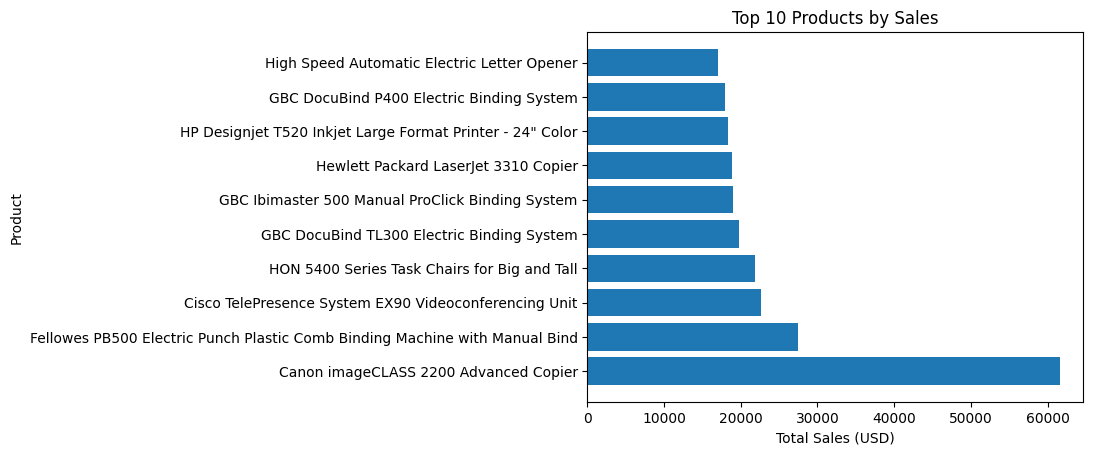

In [68]:
# exploratory tests made during the analysis — kept commented as a record of the process
# top 10 products by total sales
top = df.groupby('Product Name')['Sales'].sum()
top_10 = top.nlargest(10)

plt.barh(top_10.index, top_10.values)
plt.xlabel('Total Sales (USD)')
plt.ylabel('Product')
plt.title('Top 10 Products by Sales')
plt.show()
